# Session 13: Exploratory Grade Analysis
This notebook creates a histogram of the final grade variable `G3`.

**Main output:** `figures/grade_distribution.png`

In [29]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path

# Update the path if needed
file_path = "../data/raw/student-mat.csv"

df = pd.read_csv(file_path, sep=";")

print("Dataset loaded successfully.")
print("Shape:", df.shape)

df.head()

Dataset loaded successfully.
Shape: (395, 33)


,school,sex,age,address,famsize,Pstatus,Medu,Fedu,Mjob,Fjob,...,famrel,freetime,goout,Dalc,Walc,health,absences,G1,G2,G3
0,GP,F,18,U,GT3,A,4,4,at_home,teacher,...,4,3,4,1,1,3,6,5,6,6
1,GP,F,17,U,GT3,T,1,1,at_home,other,...,5,3,3,1,1,3,4,5,5,6
2,GP,F,15,U,LE3,T,1,1,at_home,other,...,4,3,2,2,3,3,10,7,8,10
3,GP,F,15,U,GT3,T,4,2,health,services,...,3,2,2,1,1,5,2,15,14,15
4,GP,F,16,U,GT3,T,3,3,other,other,...,4,3,2,1,2,5,4,6,10,10


In [30]:
# Verify column G3
if "G3" in df.columns:
    print("G3 column exists. Ready to plot.")
else:
    raise ValueError("The column 'G3' was not found. Check the separator.")

# Display final grade summary
print("\nSummary of final grade G3:")
print(df["G3"].describe())
print("\nNumber of students with G3 = 0:", (df["G3"] == 0).sum())
print("Percentage of students with G3 = 0:", round((df["G3"] == 0).mean() * 100, 2), "%")

G3 column exists. Ready to plot.

Summary of final grade G3:
count    395.000000
mean      10.415190
std        4.581443
min        0.000000
25%        8.000000
50%       11.000000
75%       14.000000
max       20.000000
Name: G3, dtype: float64

Number of students with G3 = 0: 38
Percentage of students with G3 = 0: 9.62 %


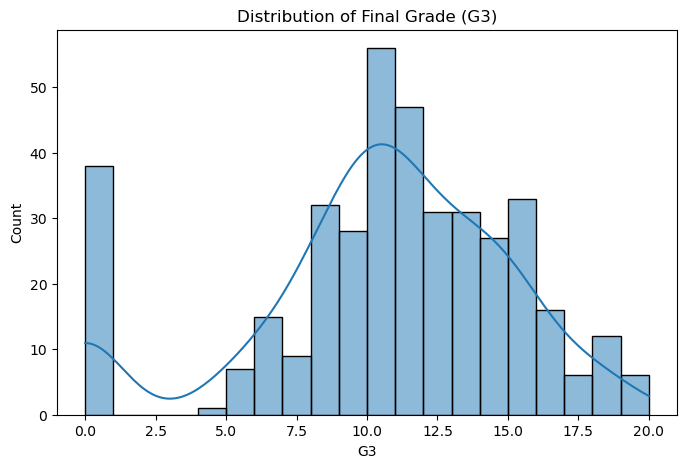

Figure saved to: ../figures/grade_distribution.png


In [31]:
# Plot histogram
plt.figure(figsize=(8, 5))
sns.histplot(df["G3"], bins=20, kde=True)
plt.title("Distribution of Final Grade (G3)")
plt.xlabel("G3")
plt.ylabel("Count")

# Save the figure
plt.savefig("../figures/grade_distribution.png", bbox_inches="tight", dpi=300)
plt.show()

print("Figure saved to: ../figures/grade_distribution.png")

## Prompt-Engineered Explanation Task
**Role:** Act as an EDA assistant.  
**Task:** Interpret a final-grade histogram for an education dataset.  
**Requirements:** 1. Describe the shape of the distribution.  
2. Note whether there is a spike at zero.  
3. Discuss implications for the pass/fail threshold.  

### Summary
The G3 histogram shows how final grades are distributed across the student population, providing vital context before any machine learning modeling. It helps determine whether we should treat student performance prediction as a regression task, a classification task, or both.

### Interpretation
The overall distribution shows that most student grades are concentrated around the middle of the scale (representing moderate performance), tapering off at the very low and very high ends. However, there is a distinct, visible spike at G3 = 0. This zero-grade cluster likely represents administrative outcomes—such as course withdrawals, chronic absenteeism, or students who missed the final exam—rather than normal academic performance.

### Recommendation
If the research team defines "passing" as G3 >= 10, any student below this threshold is labeled as failing. Because the zero-grade group is likely structurally different from students who finished the class with a low grade (e.g., a 9), we must document whether we keep them in the failure class, remove them, or analyze them separately. This decision directly impacts our class balance, model accuracy, and the recall of our risk predictions.

## Reflection Question
**Question:** What might a cluster of zero final grades represent in a real school?

**Answer:**
In a real school setting, a zero grade rarely means a student completed all coursework and earned zero points. Instead, it typically indicates non-completion, class withdrawal, zero attendance, or administrative placeholders for missing exam records. 

For machine learning, this is crucial: if we train a model on these zero-grade students without distinguishing them, the model might accidentally learn predictors of "course drop-out" rather than "poor academic comprehension."

Rows used in this analysis: 395

Number of students in each study-time group:
studytime
1    105
2    198
3     65
4     27
Name: count, dtype: int64

Mean final grade by study-time group:
studytime
1    10.05
2    10.17
3    11.40
4    11.26
Name: G3, dtype: float64


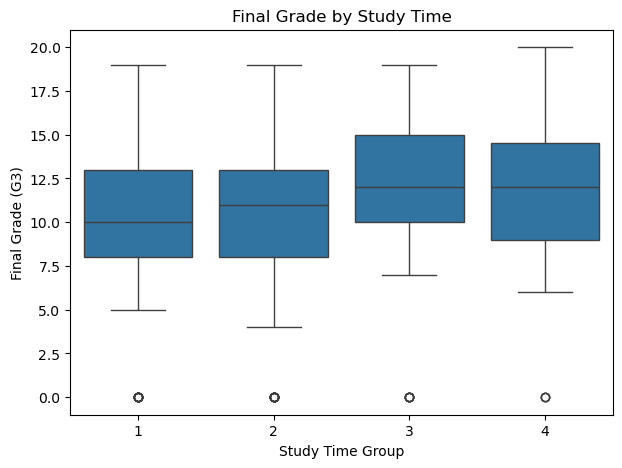


Saved figure: ../figures/studytime_vs_grade.png


In [32]:
# Session 14 Study Time and Performance Analysis (Google Colab)
import os
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Confirm df is loaded
try:
    df
except NameError:
    raise NameError("df is not loaded. Run the data-loading cell first.")

# Ensure numeric values and drop missing data
df["studytime"] = pd.to_numeric(df["studytime"], errors="coerce")
df["G3"] = pd.to_numeric(df["G3"], errors="coerce")
plot_df = df.dropna(subset=["studytime", "G3"]).copy()
plot_df["studytime"] = plot_df["studytime"].astype(int)

# Print basic dataset counts
print("Rows used in this analysis:", len(plot_df))
print("\nNumber of students in each study-time group:")
print(plot_df["studytime"].value_counts().sort_index())

# Compute mean final grade by study-time group
print("\nMean final grade by study-time group:")
mean_grades = plot_df.groupby("studytime")["G3"].mean().round(2)
print(mean_grades)

# Create the boxplot
plt.figure(figsize=(7, 5))
sns.boxplot(x="studytime", y="G3", data=plot_df)
plt.title("Final Grade by Study Time")
plt.xlabel("Study Time Group")
plt.ylabel("Final Grade (G3)")

# Save the figure locally in Colab
plt.savefig("../figures/studytime_vs_grade.png", bbox_inches="tight", dpi=300)
plt.show()

print("\nSaved figure: ../figures/studytime_vs_grade.png")

## Session 14 Finding: Study Time and Final Grade
The figure `studytime_vs_grade.png` compares final grade `G3` across the four `studytime` groups. 

The boxplot and mean-grade comparison suggest that study time may be associated
with final grade. Students in higher study-time groups may show higher average
final grades than students in the lowest study-time group. However, the pattern
should be checked carefully because the trend may not be perfectly monotonic across
all four study-time levels.
This analysis does not prove that more study time causes higher grades. The plot
only shows an association. Other factors, such as prior grades, absences, failures,
motivation, family support, and school support, may also influence final grade.
A useful follow-up would be to compare study time with other predictors in a
regression model or machine learning model to evaluate whether `studytime` remains
important after accounting for other variables.

In [33]:
# Session 15
required_columns = ["failures", "absences", "G3"]

for col in required_columns:
    print(col, col in df.columns)

failures True
absences True
G3 True


In [34]:
analysis_df = df[["failures", "absences", "G3"]].dropna().copy()
analysis_df.groupby("failures")["G3"].mean()

failures
0    11.253205
1     8.120000
2     6.235294
3     5.687500
Name: G3, dtype: float64

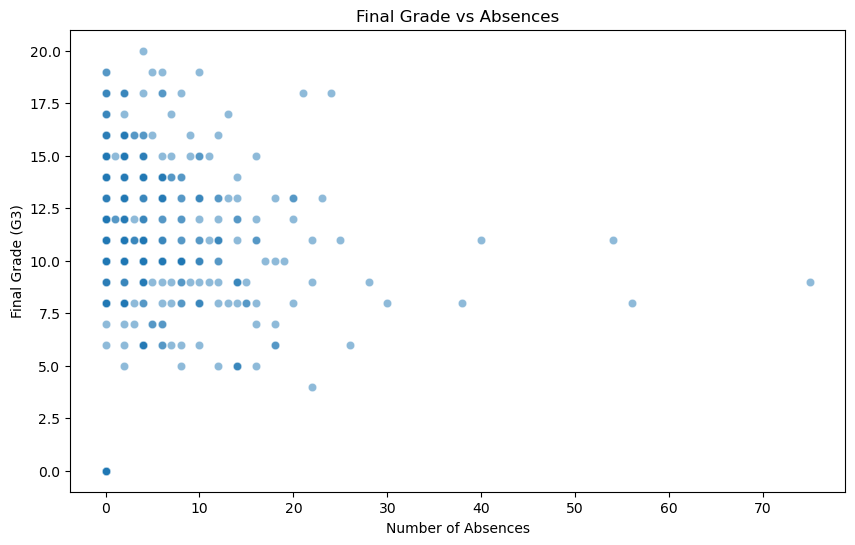

<Figure size 640x480 with 0 Axes>

In [35]:
plt.figure(figsize=(10,6))

sns.scatterplot(
    x="absences",
    y="G3",
    data=analysis_df,
    alpha=0.5
)

plt.title("Final Grade vs Absences")

plt.xlabel("Number of Absences")

plt.ylabel("Final Grade (G3)")

plt.show()

plt.savefig(
    "../figures/absences_vs_grade.png",
    dpi=300,
    bbox_inches="tight"
)

In [36]:
analysis_df["absences"].corr(
    analysis_df["G3"]
)


0.03424731615006931

In [37]:
analysis_df[
    ["failures", "absences", "G3"]
].corr()

,failures,absences,G3
failures,1.000000,0.063726,-0.360415
absences,0.063726,1.000000,0.034247
G3,-0.360415,0.034247,1.000000


In [38]:
df[
    ["failures","absences","studytime","G3"]
].corr(numeric_only=True)["G3"]

failures    -0.360415
absences     0.034247
studytime    0.097820
G3           1.000000
Name: G3, dtype: float64

# Session 15 Prompt-Engineered Interpretation

## Summary

The analysis examined how past failures and absences relate to students' final grades (`G3`). Students with **0 past failures** had an average final grade of **[ENTER VALUE]**, compared with **[ENTER VALUE]** for students with **1 past failure**, **[ENTER VALUE]** for students with **2 past failures**, and **[ENTER VALUE]** for students with **3 or more past failures**. This pattern indicates that students with more previous failures generally earn lower final grades.

The correlation between **failures** and **G3** was **-0.360**, indicating a moderate negative relationship. The correlation between **absences** and **G3** was **0.034**, indicating almost no linear relationship in this dataset. Based on the grouped averages, correlation values, and scatterplot, **past failures appear to be the stronger predictor** of final grade.

---

## Interpretation

The grouped results suggest that the average final grade decreases as the number of previous failures increases. This indicates that prior academic difficulties are associated with lower final grades. However, this relationship represents an **association**, not proof that previous failures cause lower grades. In addition, the groups with two or three previous failures may contain fewer students, so those averages should be interpreted with caution.

The scatterplot comparing absences and final grade shows substantial variation. Most students have relatively few absences, but students with similar absence counts earned a wide range of final grades. A few students with many absences still achieved moderate grades, while some students with very few absences earned lower grades. This visual pattern is consistent with the correlation coefficient (**0.034**), which suggests that absences alone are not a meaningful linear predictor of final grade in this dataset.

When comparing the two variables, **past failures appear to be the stronger predictor** because they show a clearer statistical relationship with final grade than absences.

---

## Recommendation

An early-warning model should use **past failures** as an initial indicator of academic risk because this information is available before or at the beginning of the school term. Although absences did not show a strong relationship with final grade in this analysis, attendance should still be monitored throughout the semester because changes in attendance may provide additional information when combined with other predictors.

The strongest early-warning system should combine multiple variables, including **past failures**, **study time**, **family support**, and other relevant student characteristics, rather than relying on a single feature. Predictions should be used to identify students who may benefit from tutoring, counseling, or other academic support instead of making disciplinary or high-stakes decisions.

---

## Student Verification Note

I reviewed the AI-generated explanation and compared it with the grouped mean results, correlation values, and scatterplot produced during the analysis. I confirmed that the explanation accurately describes associations rather than causation and does not introduce unsupported numerical claims. The conclusions are based on the actual outputs generated from the dataset.

In [39]:
# Session 16: Family and school-support analysis
support_features = ["schoolsup", "famsup", "higher"]
for col in support_features:
    print("=" * 60)
    print(f"Final-grade summary by {col}")
    
    summary = (
        df.groupby(col)["G3"]
        .agg(
            student_count="count",
             mean_G3="mean",
             median_G3="median",
            standard_deviation="std"
        )
    .round(2)
    )
    display(summary)

Final-grade summary by schoolsup


,student_count,mean_G3,median_G3,standard_deviation
schoolsup,,,,
no,344,10.56,11.0,4.77
yes,51,9.43,10.0,2.87


Final-grade summary by famsup


,student_count,mean_G3,median_G3,standard_deviation
famsup,,,,
no,153,10.64,11.0,4.64
yes,242,10.27,11.0,4.55


Final-grade summary by higher


,student_count,mean_G3,median_G3,standard_deviation
higher,,,,
no,20,6.80,8.0,4.83
yes,375,10.61,11.0,4.49


In [40]:
# Compare the mean grade of the yes and no groups
support_differences = []
for col in ["schoolsup", "famsup", "higher"]:
    means = df.groupby(col)["G3"].mean()
    no_mean = means.get("no")
    yes_mean = means.get("yes")
    
    support_differences.append({
        "feature": col,
        "mean_G3_no": no_mean,
        "mean_G3_yes": yes_mean,
        "difference_yes_minus_no": yes_mean - no_mean
    })
support_difference_table = pd.DataFrame(
    support_differences
).round(2)

display(support_difference_table)

,feature,mean_G3_no,mean_G3_yes,difference_yes_minus_no
0,schoolsup,10.56,9.43,-1.13
1,famsup,10.64,10.27,-0.37
2,higher,6.80,10.61,3.81


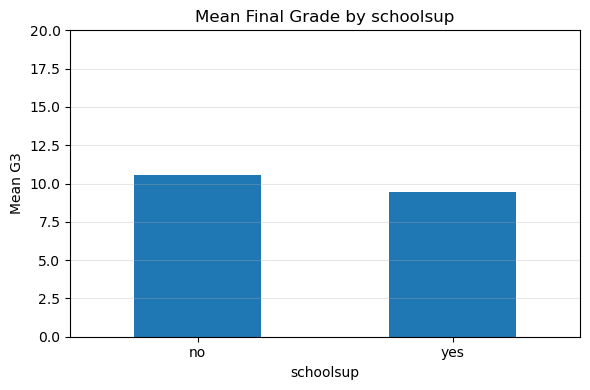

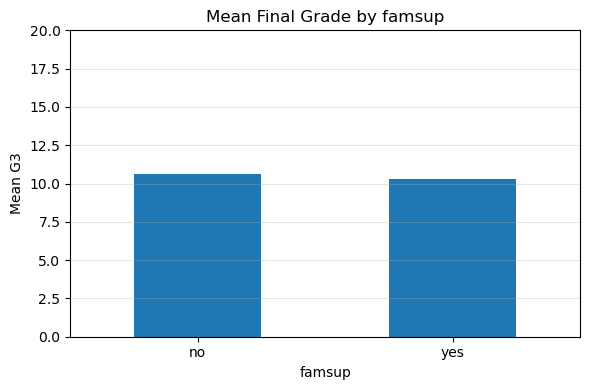

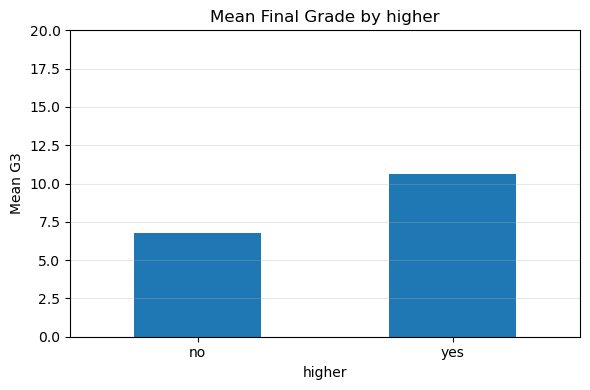

In [41]:
for col in ["schoolsup", "famsup", "higher"]:
    mean_grades = (
        df
        .groupby(col)["G3"]
        .mean()
        .sort_index()
    )

    plt.figure(figsize=(6, 4))
    mean_grades.plot(kind="bar")

    plt.title(f"Mean Final Grade by {col}")
    plt.xlabel(col)
    plt.ylabel("Mean G3")
    plt.xticks(rotation=0)
    plt.ylim(0, 20)
    plt.grid(axis="y", alpha=0.3)
    plt.tight_layout()
    plt.show()

In [42]:
feature_labels = {
    "schoolsup": "school support",
    "famsup": "family support",
    "higher": "aspiration for higher education"
}
for _, row in support_difference_table.iterrows():
    feature = row["feature"]
    difference = row["difference_yes_minus_no"]

    print(f"\nFeature: {feature_labels[feature]}")
    print(f"Mean G3 for 'no': {row['mean_G3_no']}")
    print(f"Mean G3 for 'yes': {row['mean_G3_yes']}")
    print(f"Difference: {difference}")

    if difference > 0:
        print(
            "Interpretation: The 'yes' group has a higher "
            "average final grade."
        )
    elif difference < 0:
        print(
            "Interpretation: The 'yes' group has a lower "
            "average final grade."
        )
    else:
        print(
            "Interpretation: The two groups have the same "
            "average final grade."
        )


Feature: school support
Mean G3 for 'no': 10.56
Mean G3 for 'yes': 9.43
Difference: -1.13
Interpretation: The 'yes' group has a lower average final grade.

Feature: family support
Mean G3 for 'no': 10.64
Mean G3 for 'yes': 10.27
Difference: -0.37
Interpretation: The 'yes' group has a lower average final grade.

Feature: aspiration for higher education
Mean G3 for 'no': 6.8
Mean G3 for 'yes': 10.61
Difference: 3.81
Interpretation: The 'yes' group has a higher average final grade.


# Session 16: Family and School-Support Analysis
## Purpose
This exploratory analysis examines how school support, family support, and
students' aspirations for higher education are associated with final academic
performance. Final performance is measured using G3, the final course grade.
## Variables
- **schoolsup:** Whether the student receives additional educational support from
the school.
- **famsup:** Whether the student receives educational support from the family.
- **higher:** Whether the student intends to pursue higher education.
- **G3:** Final course grade.
## Numerical Results
### School Support
- Mean G3 without school support: **10.56**
- Mean G3 with school support: **9.43**
- Difference, yes minus no: **-1.13**
- Number of students without school support: **344**
- Number of students with school support: **51**
### Family Support
- Mean G3 without family support: **10.64**
- Mean G3 with family support: **10.27**
- Difference, yes minus no: **-0.37**
- Number of students without family support: **153**
- Number of students with family support: **242**
### Higher-Education Aspiration
- Mean G3 without higher-education aspiration: **6.80**
- Mean G3 with higher-education aspiration: **10.61**
- Difference, yes minus no: **3.81**
- Number of students without higher-education aspiration: **20**
- Number of students with higher-education aspiration: **375**

## Interpretation
The school-support comparison showed that students receiving school support had a
**lower** average final grade. If the supported group had a lower
average, this should not be interpreted as evidence that school support reduced
student performance. Students with existing academic difficulties may have been
more likely to receive support.
The family-support comparison showed a **limited** descriptive
relationship with final grades.
The higher-education comparison showed a **positive** descriptive
relationship with final grades.
## Confounding Considerations
Prior academic performance may affect both whether a student receives support and
the student's final grade. Other possible confounding variables include previous
failures, attendance, study time, motivation, learning difficulties, family
background, and socioeconomic conditions.
These results describe associations only and do not establish causal effects.
## Recommendations
- Retain **schoolsup** because it may identify students receiving academic
intervention or students with greater prior academic need.
- Retain **famsup** because it provides potentially useful family-context
information.
- Retain **higher** because educational aspiration may reflect motivation,
expectations, and future academic goals.
- Evaluate all three variables later in multivariable models rather than relying
only on unadjusted group means.
## Reflection
If school support is associated with lower grades, a likely confounding explanation
is that students who were already struggling academically were more likely to
receive support. Their lower final grades may reflect prior academic risk rather
than a harmful effect of the support itself.
## Conclusion
School support, family support, and higher-education aspiration showed different
descriptive relationships with final grades. The findings justify retaining all
three features for later analysis, while interpreting them cautiously because of
possible confounding and selection effects.